In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchmetrics import ConfusionMatrix
from torch.utils.data import DataLoader, random_split, Dataset
from PIL import Image
import torchvision.models as models
import cv2
import os, shutil
import numpy as np
from torchsummary import summary
import matplotlib.pyplot as plt
#from google.colab import drive

/home/avaslih/My_VENV/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Mount Google Drive
#drive.mount('/content/drive')
#!unzip /content/drive/MyDrive/Dataset/archive.zip -d /content/drive/MyDrive/Dataset/

In [ ]:
# # reorganize the dataset
# # training
# # # Path to your main images folder
# src_dir = "/content/drive/MyDrive/Dataset/datasets/train/images"
# dst_dir = "/content/drive/MyDrive/Dataset/datasets//train/all_images"  # where you want the class folders created
# # # Make sure destination exists
# os.makedirs(dst_dir, exist_ok=True)

# # # Loop through every file in the source directory
# for filename in os.listdir(src_dir):
#      if not filename.lower().endswith(('.jpg')):
#           continue  # skip non-image files

# #     # Extract class name from filename
# #     # Example: "cat_001.jpg" → "cat"
#      class_name = filename.split('_')[3]  # adjust this to match your naming pattern

#      # Create class folder if it doesn’t exist
#      class_folder = os.path.join(dst_dir, class_name)
#      os.makedirs(class_folder, exist_ok=True)

# #     # Move file into that folder
#      src_path = os.path.join(src_dir, filename)
#      dst_path = os.path.join(class_folder, filename)
#      shutil.move(src_path, dst_path)
# print("✅ Images organized successfully!")


# # validating
# # # Path to your main images folder
# src_dir = "/content/drive/MyDrive/Dataset/datasets/valid/images"
# dst_dir = "/content/drive/MyDrive/Dataset/datasets/valid/all_images"  # where you want the class folders created

#  # Make sure destination exists
# os.makedirs(dst_dir, exist_ok=True)

#  # Loop through every file in the source directory
# for filename in os.listdir(src_dir):
#      if not filename.lower().endswith(('.jpg')):
#          continue  # skip non-image files

#      # Extract class name from filename
#      # Example: "cat_001.jpg" → "cat"
#      class_name = filename.split('_')[3]  # adjust this to match your naming pattern

#      # Create class folder if it doesn’t exist
#      class_folder = os.path.join(dst_dir, class_name)
#      os.makedirs(class_folder, exist_ok=True)

#      # Move file into that folder
#      src_path = os.path.join(src_dir, filename)
#      dst_path = os.path.join(class_folder, filename)
#      shutil.move(src_path, dst_path)

# print("✅ Images organized successfully!")


In [8]:

data_dir = "/home/avaslih/Desktop/Machine Learning/archive/datasets/" #Dataset Path

# Transformations to make all images the same
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to a consistent size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Normalize


    # Apply Augmentations to make the model used to different situations
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),

])

# Load the dataset from the path
train_dataset = datasets.ImageFolder(root=data_dir + "/train/all_images", transform=transform)
remain_dataset = datasets.ImageFolder(root=data_dir + "/valid/all_images", transform=transform)

# split the remaining dataset into validation and testing
test_size = int(0.5 * len(remain_dataset))
val_size = len(remain_dataset) - test_size
test_dataset, val_dataset = random_split(remain_dataset, [test_size, val_size])

#load the dataset into the DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f'Dataset Loaded')

Dataset Loaded


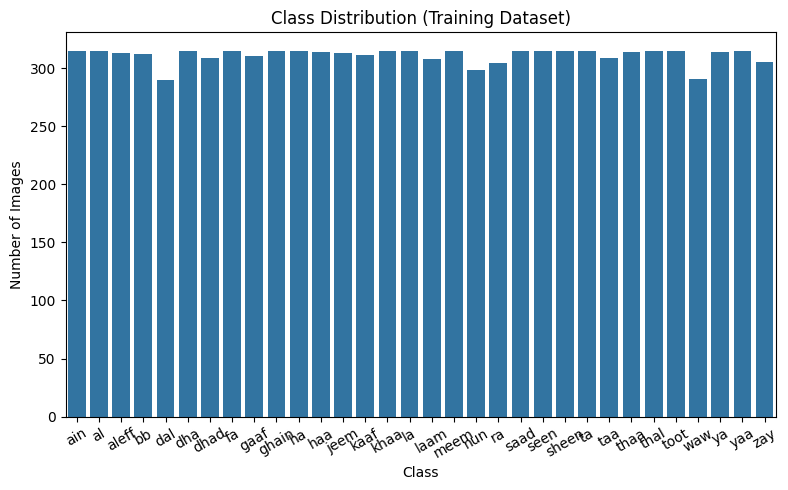

In [201]:
# Get class names and counts
class_names = train_dataset.classes
class_counts = [0] * len(class_names)

for _, label in train_dataset.samples:
    class_counts[label] += 1

# Plot the class distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=class_counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Training Dataset)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [152]:
# Define the model

num_classes = len(train_dataset.classes) #get the number of classes in the dataset
model = models.resnet18(pretrained=True) #load the resnet18 model

#change the last fully connected layer in the network to the number of classes in our dataset (32)
model.fc = nn.Linear(model.fc.in_features, num_classes) 
print(model(torch.randn(1, 3, 224, 224)).shape) #print the new shape of the model



# Move the model to the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

torch.Size([1, 32])


In [153]:
summary(model, (3, 224, 244))# print a summary of the model

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 122]           9,408
       BatchNorm2d-2         [-1, 64, 112, 122]             128
              ReLU-3         [-1, 64, 112, 122]               0
         MaxPool2d-4           [-1, 64, 56, 61]               0
            Conv2d-5           [-1, 64, 56, 61]          36,864
       BatchNorm2d-6           [-1, 64, 56, 61]             128
              ReLU-7           [-1, 64, 56, 61]               0
            Conv2d-8           [-1, 64, 56, 61]          36,864
       BatchNorm2d-9           [-1, 64, 56, 61]             128
             ReLU-10           [-1, 64, 56, 61]               0
       BasicBlock-11           [-1, 64, 56, 61]               0
           Conv2d-12           [-1, 64, 56, 61]          36,864
      BatchNorm2d-13           [-1, 64, 56, 61]             128
             ReLU-14           [-1, 64,

In [154]:
#training cycle
num_epochs = 15 #train for 15 epochs
for epoch in range(num_epochs):
    for images, labels in train_loader: #get the images and labels from the train_loader
        images, labels = images.to(device), labels.to(device) #put the images and labels to the device (GPU)

        optimizer.zero_grad() #reset the gradient for each image to recalculate the loss
        outputs = model(images) #get the output of the current image

        loss = criterion(outputs, labels) #calculate the loss compare to the actual label
        loss.backward() #backbropagate to calculate the loss
        optimizer.step()

    #initialize the correct prediction compared to total to calculate the accuracy
    correct = 0
    total = 0
    with torch.no_grad():
        #calculate the accuracy of the model in the validation set
      for images, labels in val_loader: # 
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

    #print the epochs results
    print(f"Epoch [{epoch+1}/{num_epochs}], Validation Accuracy: {100 * correct / total:.2f}%")

Epoch [1/15], Validation Accuracy: 46.94%
Epoch [2/15], Validation Accuracy: 67.14%
Epoch [3/15], Validation Accuracy: 70.67%
Epoch [4/15], Validation Accuracy: 70.95%
Epoch [5/15], Validation Accuracy: 74.91%
Epoch [6/15], Validation Accuracy: 77.97%
Epoch [7/15], Validation Accuracy: 77.26%
Epoch [8/15], Validation Accuracy: 77.92%
Epoch [9/15], Validation Accuracy: 79.90%
Epoch [10/15], Validation Accuracy: 77.02%
Epoch [11/15], Validation Accuracy: 79.33%
Epoch [12/15], Validation Accuracy: 78.91%
Epoch [13/15], Validation Accuracy: 78.58%
Epoch [14/15], Validation Accuracy: 77.35%
Epoch [15/15], Validation Accuracy: 79.85%


In [155]:
#save the model
PATH = "resnet18.pth"
torch.save(model.state_dict(), PATH)

In [6]:
#Load the model
PATH = "resnet18.pth"
num_classes = 32
loaded_state_dict = torch.load(PATH)
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(loaded_state_dict)

<All keys matched successfully>

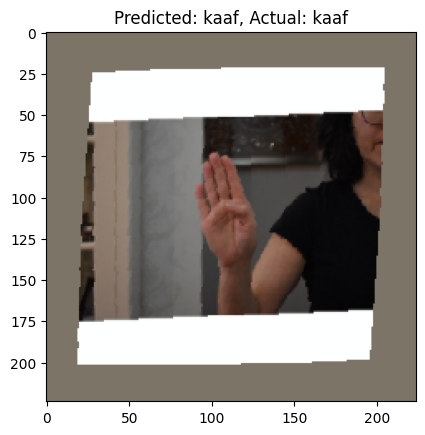

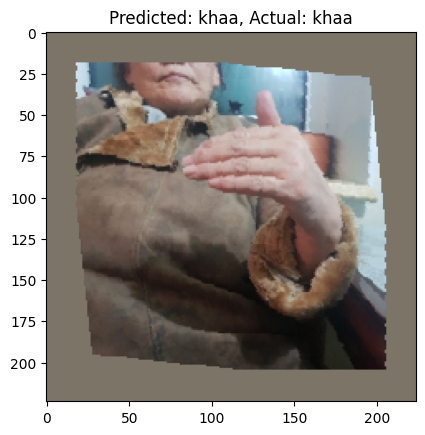

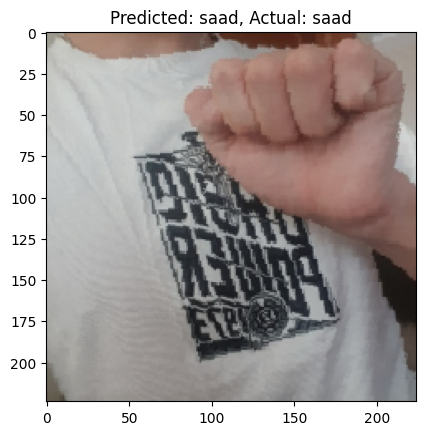

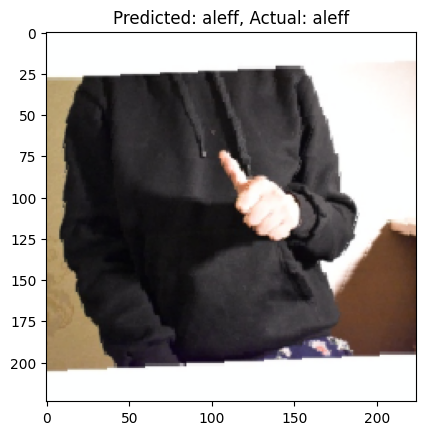

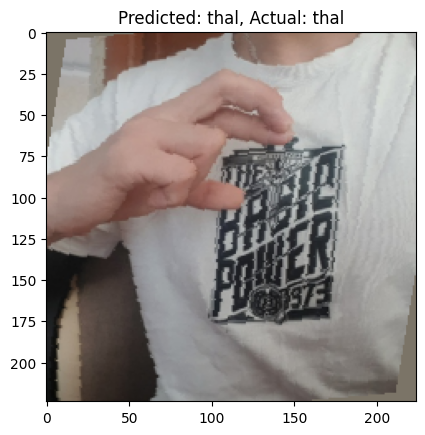

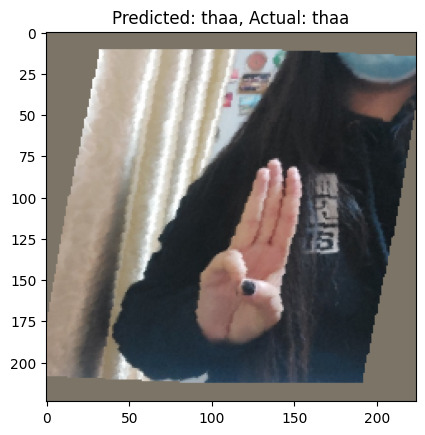

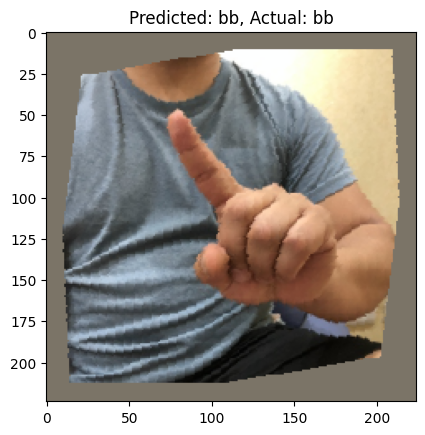

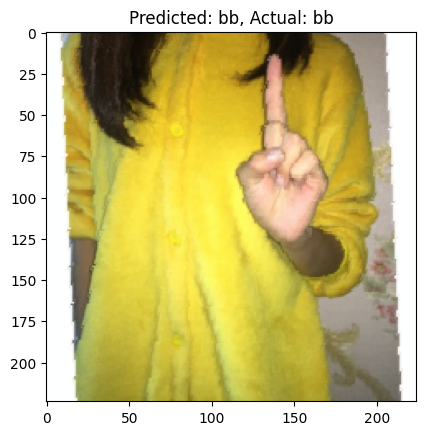

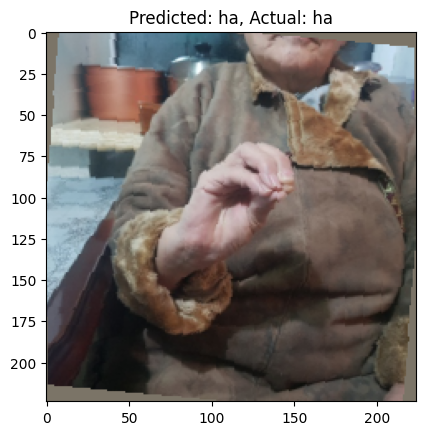

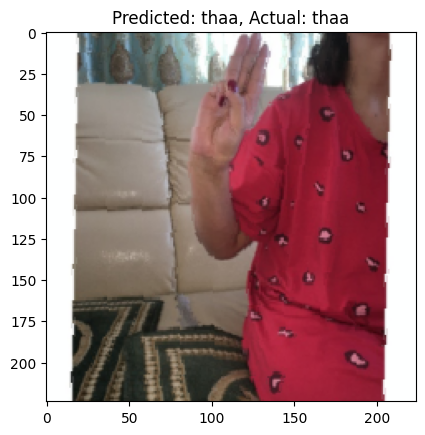

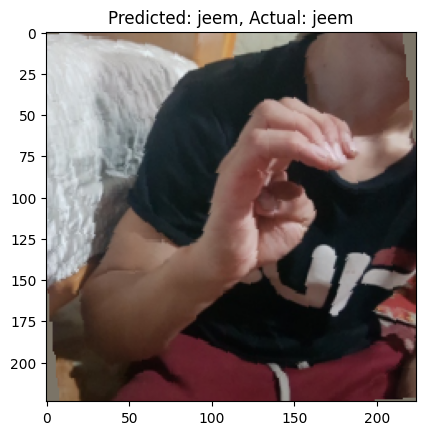

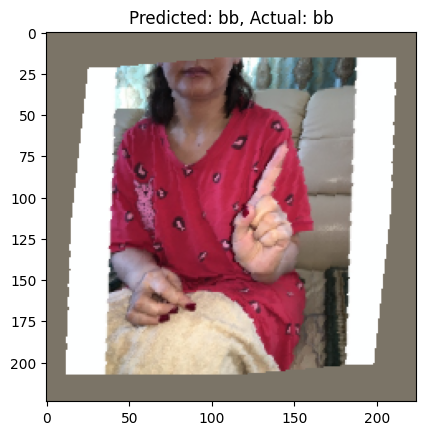

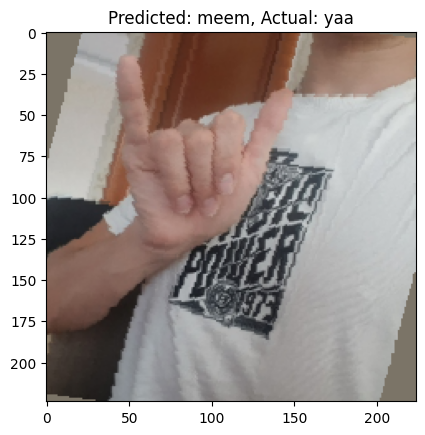

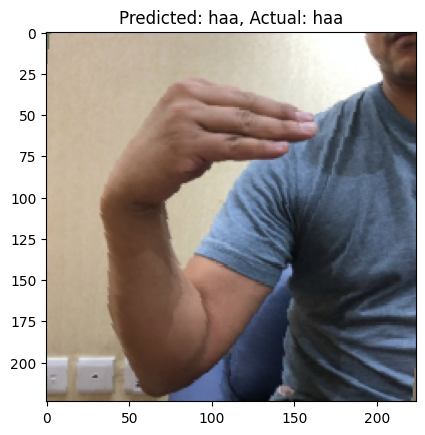

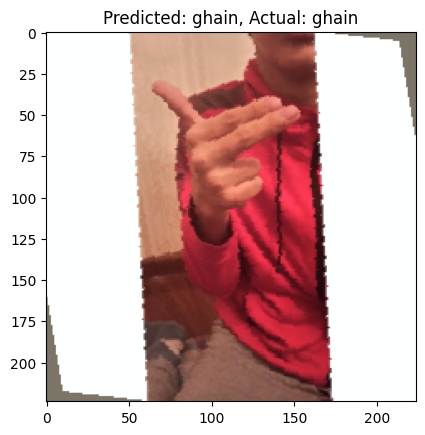

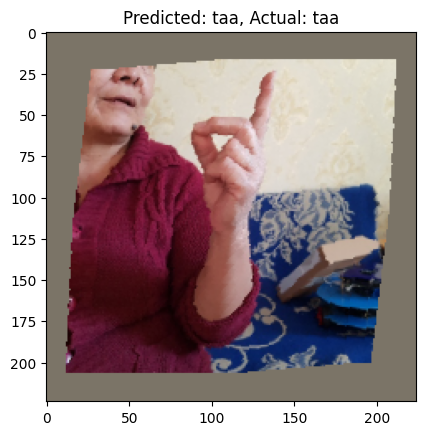

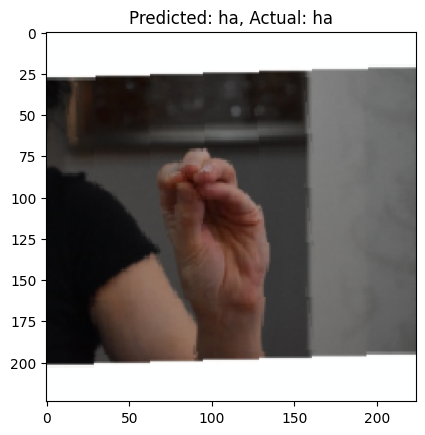

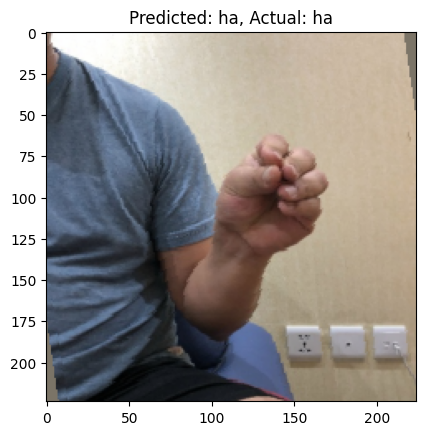

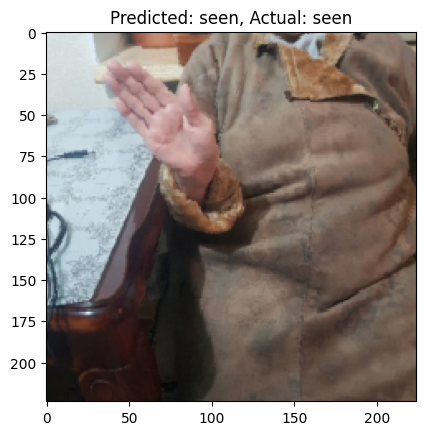

Testing Accuracy: 80.88%


In [9]:
# Read image from the dataset
idx = 0
correct = 0
total = 0
pred = []
target = []
#calculate the accuracy of the model in the validation set
for images, labels in test_loader:  
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    idx += 1
    if(idx < 20):
        img = images[0].cpu().numpy().transpose((1, 2, 0))
        img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
    
        plt.imshow(img)
        plt.title(f"Predicted: {test_dataset.dataset.classes[int(predicted[0])]}, Actual: {test_dataset.dataset.classes[int(labels[0])]}")
        plt.show()
    pred.append(predicted)
    target.append(labels)

pred = torch.cat(pred)
target = torch.cat(target)
print(f"Testing Accuracy: {100 * correct / total:.2f}%")

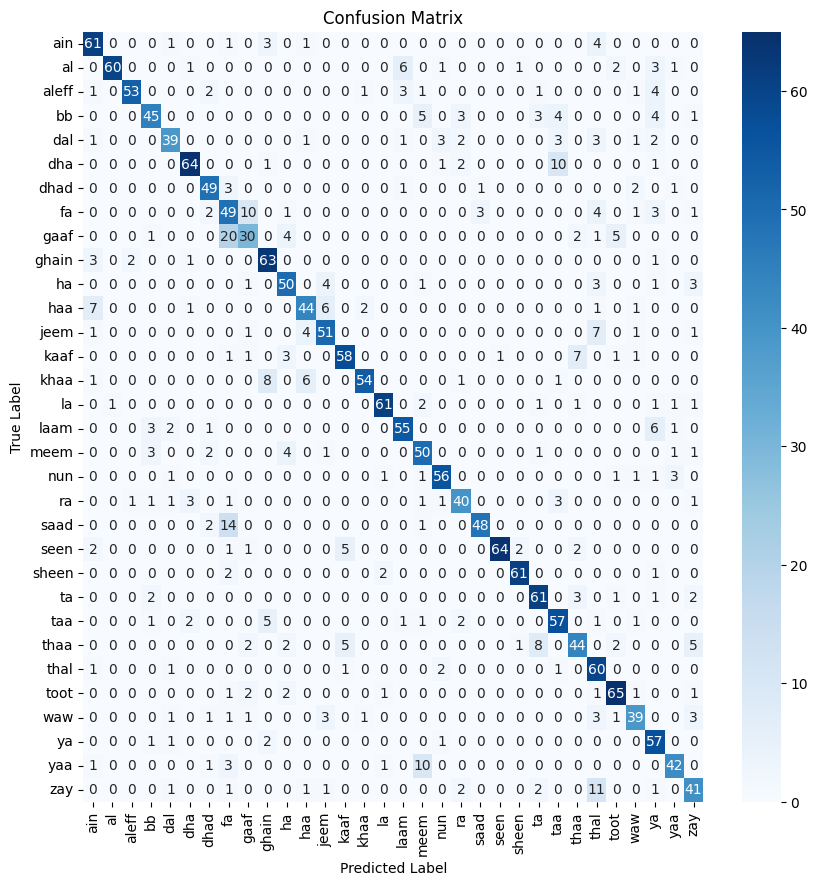

In [198]:
confmat = ConfusionMatrix(task="multiclass", num_classes=num_classes)
cm = confmat(pred, target)

# --- Display confusion matrix ---
plt.figure(figsize=(10, 10))
sns.heatmap(cm.numpy(), annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.dataset.classes,
            yticklabels=test_dataset.dataset.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()